# Chess Elo Regression — Advanced Game + Clock Features

This notebook:
- Parses the **annotated Lichess PGN format** (`{ [%clk ...] [%eval ...] }` comments)
- Extracts **34 hand-crafted features** via `chess_features.py` including clock/time-management signals
- Uses **inverse-frequency sample weights** so rare high-Elo games count more
- Measures feature importance with **permutation importance** (parallelised with joblib)

In [36]:
# pip install chess zstandard lightgbm pandas scikit-learn matplotlib joblib

import io, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
import lightgbm as lgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import randint, loguniform
from scipy.sparse import csr_matrix, hstack
from joblib import Parallel, delayed

# chess_features.py must live in the same directory as this notebook
from chess_features import extract_features_dataframe, compute_elo_sample_weights

print('All imports OK')

All imports OK


In [37]:
# ── global config ─────────────────────────────────────────────────────────────
DATA_PATH    = "../../data/villads_data/lichess_db_standard_rated_2017-11.pgn.zst"
MAX_GAMES    = 20_000
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_JOBS       = -1   # use all CPU cores

# Elo bin edges for stratified weighting
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

# Feature groups produced by chess_features.py
NUMERIC_FEATURES = [
    "total_ply_count", "material_balance_end",
    "checks_given_white", "checks_given_black",
    "first_capture_move_white", "first_capture_move_black",
    "pawn_captures_total", "piece_captures_total",
    "castle_move_white", "castle_move_black",
    "result_encoded",
    "consec_same_piece_white", "consec_same_piece_black",
    "queen_moves_before_10",
    "white_territory_depth", "black_territory_depth",
    "promotions", "en_passant_captures",
    "legal_moves_white_move5", "legal_moves_black_move5",
    # clock features (normalized by time control base)
    "avg_time_per_move_white_norm", "std_time_per_move_white_norm",
    "max_time_single_move_white_norm", "time_pressure_moves_white",
    "opening_pace_white_norm", "clock_remaining_white_norm",
    "avg_time_per_move_black_norm", "std_time_per_move_black_norm",
    "max_time_single_move_black_norm", "time_pressure_moves_black",
    "opening_pace_black_norm", "clock_remaining_black_norm",
]
CATEGORICAL_FEATURES = ["castle_side_white", "castle_side_black"]
METADATA_FEATURES    = ["TimeControl", "ECO"]

LGBM_CONFIG = {
    "n_estimators":      500,
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "random_state":      RANDOM_STATE,
    "verbose":           -1,
    "n_jobs":            N_JOBS,
}

## 1 · Parse annotated PGN
The new Lichess format includes inline `{ [%clk H:MM:SS] [%eval x.xx] }` comments.
We read the **full PGN block** per game (headers + annotated moves) so
`chess_features.py` can extract clock times directly from each move node.

In [38]:
games_list = []
dctx = zstd.ZstdDecompressor()

with open(DATA_PATH, "rb") as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding="utf-8")
        current_game = {}

        for line in text_stream:
            line = line.strip()

            if line.startswith('['):
                tag = line.split(' ')[0][1:]
                val = line.split('"')[1]
                if tag in ['WhiteElo', 'BlackElo', 'TimeControl', 'ECO', 'Termination', 'Result']:
                    current_game[tag] = val

            elif line.startswith('1.'):
                current_game['Moves'] = line
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                current_game = {}
                if len(games_list) >= MAX_GAMES:
                    break

df_raw = pd.DataFrame(games_list)
df_raw['WhiteElo'] = pd.to_numeric(df_raw['WhiteElo'], errors='coerce')
df_raw['BlackElo'] = pd.to_numeric(df_raw['BlackElo'], errors='coerce')
df_raw = df_raw.dropna(subset=['WhiteElo', 'BlackElo']).copy()
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)
df_raw['Moves']    = df_raw['Moves'].fillna('').astype(str)

print(f"Loaded {len(df_raw):,} games")
df_raw.head(3)

Loaded 20,000 games


,Result,WhiteElo,BlackElo,ECO,TimeControl,Termination,Moves
0,0-1,1391,1411,C20,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:05:00] }...
1,0-1,1626,1620,B56,180+0,Time forfeit,1. e4 { [%clk 0:03:00] } c5 { [%clk 0:03:00] }...
2,1-0,1374,1350,B30,600+0,Normal,1. e4 { [%clk 0:10:00] } c5 { [%clk 0:05:00] }...


In [39]:

_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')

def parse_clock_features(moves_string: str, time_control: str = '?') -> dict:
    """
    Extract all [%clk] readings from the flat moves string and derive
    time-management features without replaying the board.
    clock readings alternate White/Black starting with White.
    """
    clocks = [
        int(h)*3600 + int(m)*60 + int(s)
        for h, m, s in _CLK_RE.findall(moves_string)
    ]

    clk_w = clocks[0::2]  # White: indices 0, 2, 4, ...
    clk_b = clocks[1::2]  # Black: indices 1, 3, 5, ...

    # parse increment from time control e.g. "300+2"
    tc_m = re.match(r'(\d+)\+(\d+)', str(time_control))
    base      = int(tc_m.group(1)) if tc_m else None
    increment = int(tc_m.group(2)) if tc_m else 0

    def time_spent(seq, start):
        if not seq:
            return []
        spent = []
        prev = start
        for clk in seq:
            if prev is not None:
                s = prev - clk + increment
                if s >= 0:
                    spent.append(s)
            prev = clk
        return spent

    spent_w = time_spent(clk_w, base)
    spent_b = time_spent(clk_b, base)

    def stats(seq):
        if not seq:
            return 0.0, 0.0, 0.0, 0.0
        a = np.array(seq)
        return float(a.mean()), float(a.std()), float(a.max()), float(a[-1])

    aw, sw, mw, _ = stats(spent_w)
    ab, sb, mb, _ = stats(spent_b)

    return {
        'avg_time_per_move_white':    aw,
        'std_time_per_move_white':    sw,
        'max_time_single_move_white': mw,
        'time_pressure_moves_white':  sum(1 for c in clk_w if c < 10),
        'opening_pace_white':         float(np.mean(spent_w[:10])) if spent_w else 0.0,
        'clock_remaining_white':      clk_w[-1] if clk_w else 0.0,
        'avg_time_per_move_black':    ab,
        'std_time_per_move_black':    sb,
        'max_time_single_move_black': mb,
        'time_pressure_moves_black':  sum(1 for c in clk_b if c < 10),
        'opening_pace_black':         float(np.mean(spent_b[:10])) if spent_b else 0.0,
        'clock_remaining_black':      clk_b[-1] if clk_b else 0.0,
    }


tc_col = df_raw['TimeControl'] if 'TimeControl' in df_raw.columns else ['?'] * len(df_raw)

clock_records = Parallel(n_jobs=N_JOBS)(
    delayed(parse_clock_features)(moves, tc)
    for moves, tc in zip(df_raw['Moves'], tc_col)
)

df_clocks = pd.DataFrame(clock_records, index=df_raw.index)
print(f"Clock features extracted for {len(df_clocks):,} games")
df_clocks.head(3)

Clock features extracted for 20,000 games


,avg_time_per_move_white,std_time_per_move_white,max_time_single_move_white,time_pressure_moves_white,opening_pace_white,clock_remaining_white,avg_time_per_move_black,std_time_per_move_black,max_time_single_move_black,time_pressure_moves_black,opening_pace_black,clock_remaining_black
0,13.346154,16.083777,63.0,0,15.3,253.0,19.615385,56.736284,300.0,0,38.0,90.0
1,6.884615,7.662732,26.0,7,5.9,1.0,3.730769,4.727641,23.0,0,3.1,83.0
2,5.979167,6.731424,32.0,0,6.2,313.0,10.255319,42.831420,300.0,0,32.8,118.0


In [40]:
# Merge happens after df_feats is built (see later cell).

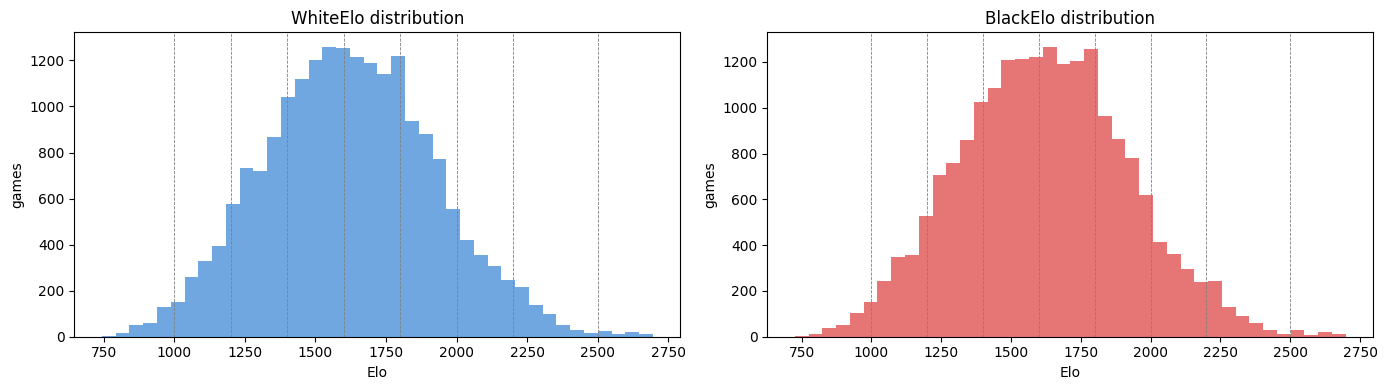

WhiteElo percentiles:
count    20000.000000
mean      1621.898950
std        300.717704
min        743.000000
5%        1135.000000
25%       1413.000000
50%       1616.000000
75%       1821.000000
90%       2006.000000
95%       2134.000000
99%       2335.000000
max       2696.000000
Name: WhiteElo, dtype: float64


In [41]:
# Elo distribution — check imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in zip(axes, ["WhiteElo", "BlackElo"], ["#4e91d9", "#e05252"]):
    ax.hist(df_raw[col], bins=40, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel("Elo")
    ax.set_ylabel("games")
    for b in ELO_BINS[1:-1]:
        ax.axvline(b, color='gray', lw=0.6, ls='--')
plt.tight_layout()
plt.show()

print("WhiteElo percentiles:")
print(df_raw["WhiteElo"].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))

## 2 · Extract features (parallel)
Each game is replayed on a real board. `n_jobs=-1` uses all CPU cores via joblib.

In [42]:
t0       = time.time()
df_feats = extract_features_dataframe(df_raw, n_jobs=N_JOBS)
elapsed  = time.time() - t0
print(f"Extracted {len(df_feats):,} games in {elapsed:.1f}s  "
      f"({elapsed/len(df_feats)*1000:.1f} ms/game)")
df_feats.head(2)

Extracted 20,000 games in 8.1s  (0.4 ms/game)


,total_ply_count,material_balance_end,checks_given_white,checks_given_black,first_capture_move_white,first_capture_move_black,pawn_captures_total,piece_captures_total,castle_move_white,castle_move_black,...,max_time_single_move_white,time_pressure_moves_white,opening_pace_white,clock_remaining_white,avg_time_per_move_black,std_time_per_move_black,max_time_single_move_black,time_pressure_moves_black,opening_pace_black,clock_remaining_black
0,52,-11,1,2,12,11,8,7,22,0,...,63.0,0,15.3,253.0,19.615385,56.736284,300.0,0,38.0,90.0
1,52,3,1,3,4,3,6,7,14,15,...,26.0,7,5.9,1.0,3.730769,4.727641,23.0,0,3.1,83.0


In [43]:
# Merge targets + metadata with extracted features and regex clock features
clock_cols = [
    "avg_time_per_move_white", "std_time_per_move_white", "max_time_single_move_white",
    "time_pressure_moves_white", "opening_pace_white", "clock_remaining_white",
    "avg_time_per_move_black", "std_time_per_move_black", "max_time_single_move_black",
    "time_pressure_moves_black", "opening_pace_black", "clock_remaining_black",
]

cols_to_drop = [col for col in clock_cols if col in df_feats.columns]
df_feats_no_clock = df_feats.drop(columns=cols_to_drop)

df = (
    df_raw[["WhiteElo", "BlackElo"] + METADATA_FEATURES]
    .join(df_feats_no_clock, how="inner")
    .join(df_clocks, how="inner")
)

base_seconds = (
    df["TimeControl"].astype(str).str.extract(r"(\d+)\+")[0].astype(float)
)

df["avg_time_per_move_white_norm"] = df["avg_time_per_move_white"] / base_seconds
df["std_time_per_move_white_norm"] = df["std_time_per_move_white"] / base_seconds
df["max_time_single_move_white_norm"] = df["max_time_single_move_white"] / base_seconds
df["opening_pace_white_norm"] = df["opening_pace_white"] / base_seconds
df["clock_remaining_white_norm"] = df["clock_remaining_white"] / base_seconds

df["avg_time_per_move_black_norm"] = df["avg_time_per_move_black"] / base_seconds
df["std_time_per_move_black_norm"] = df["std_time_per_move_black"] / base_seconds
df["max_time_single_move_black_norm"] = df["max_time_single_move_black"] / base_seconds
df["opening_pace_black_norm"] = df["opening_pace_black"] / base_seconds
df["clock_remaining_black_norm"] = df["clock_remaining_black"] / base_seconds

df = df.replace([np.inf, -np.inf], np.nan)

print(df.shape)
df.describe().round(2)

(20000, 48)


,WhiteElo,BlackElo,total_ply_count,material_balance_end,checks_given_white,checks_given_black,first_capture_move_white,first_capture_move_black,pawn_captures_total,piece_captures_total,...,avg_time_per_move_white_norm,std_time_per_move_white_norm,max_time_single_move_white_norm,opening_pace_white_norm,clock_remaining_white_norm,avg_time_per_move_black_norm,std_time_per_move_black_norm,max_time_single_move_black_norm,opening_pace_black_norm,clock_remaining_black_norm
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,...,19734.00,19734.00,19734.00,19734.00,19734.00,19734.00,19734.00,19734.00,19734.00,19734.00
mean,1621.90,1620.59,66.86,0.08,2.64,2.42,6.70,6.08,7.25,8.68,...,0.02,0.02,0.11,0.02,0.37,0.02,0.02,0.11,0.02,0.37
std,300.72,301.75,30.79,8.37,3.23,3.11,3.48,3.46,3.50,3.67,...,0.01,0.02,0.08,0.01,0.37,0.01,0.02,0.08,0.01,0.34
min,743.00,726.00,0.00,-54.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1413.00,1409.00,46.00,-5.00,0.00,0.00,4.00,3.00,5.00,6.00,...,0.02,0.01,0.06,0.01,0.08,0.02,0.01,0.06,0.01,0.07
50%,1616.00,1617.00,63.00,0.00,2.00,1.00,6.00,5.00,7.00,9.00,...,0.02,0.02,0.09,0.01,0.31,0.02,0.02,0.09,0.01,0.31
75%,1821.00,1819.00,84.00,5.00,4.00,3.00,9.00,8.00,10.00,12.00,...,0.03,0.03,0.13,0.02,0.60,0.03,0.03,0.13,0.02,0.60
max,2696.00,2699.00,289.00,45.00,36.00,49.00,27.00,28.00,16.00,19.00,...,0.50,0.40,1.40,0.50,23.93,0.39,0.33,2.02,0.32,14.95


## 3 · Balanced sample weights
Rare high-Elo games are up-weighted by the inverse frequency of their Elo stratum,
so the model doesn't just optimise for the crowded 1200–1800 band.

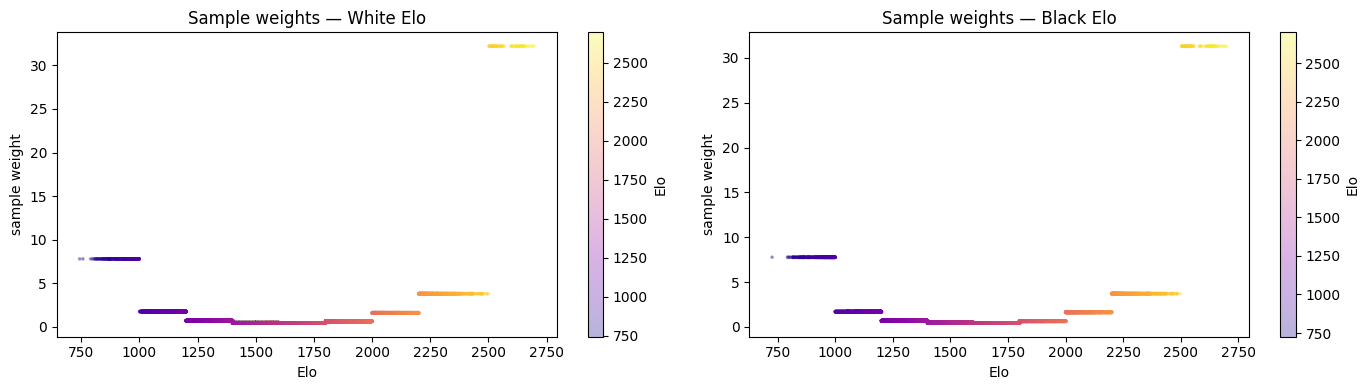

White weight stats:  min=0.453  mean=1.000  max=32.2


In [44]:
weights_white = compute_elo_sample_weights(df["WhiteElo"], ELO_BINS)
weights_black = compute_elo_sample_weights(df["BlackElo"], ELO_BINS)

# Visualise weight distribution vs Elo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, elo, w, title in zip(
    axes,
    [df["WhiteElo"], df["BlackElo"]],
    [weights_white, weights_black],
    ["White Elo", "Black Elo"],
):
    sc = ax.scatter(elo, w, s=3, alpha=0.3, c=elo, cmap="plasma")
    plt.colorbar(sc, ax=ax, label="Elo")
    ax.set_xlabel("Elo")
    ax.set_ylabel("sample weight")
    ax.set_title(f"Sample weights — {title}")
plt.tight_layout()
plt.show()

print(f"White weight stats:  min={weights_white.min():.3f}  "
      f"mean={weights_white.mean():.3f}  max={weights_white.max():.1f}")

## 4 · Build feature matrix

In [45]:
def build_matrix(frame: pd.DataFrame):
    """Build a feature matrix with robust imputation + one-hot encoding."""
    numeric_features = NUMERIC_FEATURES
    categorical_features = CATEGORICAL_FEATURES + METADATA_FEATURES

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ],
        remainder="drop",
    )

    X_local = preprocessor.fit_transform(frame)
    feature_names = list(preprocessor.get_feature_names_out())
    return X_local, feature_names


X, all_feature_names = build_matrix(df)
print(f"Feature matrix: {X.shape}  ({len(all_feature_names)} named features)")

Feature matrix: (20000, 575)  (575 named features)


## 5 · Train with balanced weights

In [46]:
def run_experiment(target_col: str, sample_weights: np.ndarray) -> dict:
    y = df[target_col].values

    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    w_train         = sample_weights[idx_train]

    model = lgb.LGBMRegressor(**LGBM_CONFIG)
    model.fit(X_train, y_train, sample_weight=w_train)
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    print(f"{target_col}  →  MAE: {mae:.1f}   RMSE: {rmse:.1f}")

    return dict(model=model, X_train=X_train, X_test=X_test,
                y_train=y_train, y_test=y_test,
                w_train=w_train, preds=preds,
                mae=mae, rmse=rmse, label=target_col,
                idx_test=idx_test)


white_run = run_experiment("WhiteElo", weights_white)
black_run = run_experiment("BlackElo", weights_black)

c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


WhiteElo  →  MAE: 188.1   RMSE: 236.5
BlackElo  →  MAE: 189.7   RMSE: 238.4


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5b · Quick random search (lightweight)
Small random search over a few LGBM hyperparameters for each target.

In [47]:
def random_search_lightgbm(target_col: str, sample_weights: np.ndarray, n_iter: int = 5):
    y = df[target_col].values

    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    w_train = sample_weights[idx_train]

    estimator = lgb.LGBMRegressor(**LGBM_CONFIG)
    param_distributions = {
        "n_estimators": randint(200, 700),
        "learning_rate": loguniform(0.02, 0.12),
        "num_leaves": randint(31, 128),
        "min_child_samples": randint(10, 60),
        "subsample": loguniform(0.7, 1.0),
        "colsample_bytree": loguniform(0.7, 1.0),
    }

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_mean_absolute_error",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=0,
    )

    search.fit(X_train, y_train, sample_weight=w_train)

    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    print(f"Best MAE for {target_col}: {mae:.1f}")
    print(f"Best params: {search.best_params_}")

    return {
        "model": best_model,
        "mae": mae,
        "params": search.best_params_,
        "X_test": X_test,
        "y_test": y_test,
        "preds": preds,
    }


rs_white = random_search_lightgbm("WhiteElo", weights_white, n_iter=5)
rs_black = random_search_lightgbm("BlackElo", weights_black, n_iter=5)

c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best MAE for WhiteElo: 197.1
Best params: {'colsample_bytree': np.float64(0.8206508190054694), 'learning_rate': np.float64(0.023923548713257182), 'min_child_samples': 20, 'n_estimators': 287, 'num_leaves': 54, 'subsample': np.float64(0.8829211905034601)}
Best MAE for BlackElo: 196.8
Best params: {'colsample_bytree': np.float64(0.8206508190054694), 'learning_rate': np.float64(0.023923548713257182), 'min_child_samples': 20, 'n_estimators': 287, 'num_leaves': 54, 'subsample': np.float64(0.8829211905034601)}


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [48]:
# Summary
pd.DataFrame([
    {"target": r["label"], "MAE": round(r["mae"], 2), "RMSE": round(r["rmse"], 2)}
    for r in [white_run, black_run]
])

,target,MAE,RMSE
0,WhiteElo,188.05,236.46
1,BlackElo,189.69,238.37


## 6 · Permutation importance (parallelised)

Permutation importance randomly shuffles one feature at a time and measures
how much the MAE increases.  Unlike split-count importance it works on the
held-out test set and is not biased toward high-cardinality features.
`n_jobs=-1` parallelises the repeats.

In [ ]:
def compute_perm_importance(run: dict, n_repeats: int = 5) -> pd.DataFrame:
    """
    Run sklearn permutation_importance on the test set.
    n_jobs=-1 parallelises across the n_repeats shuffles.
    """
    print(f"Computing permutation importance for {run['label']} "
          f"({n_repeats} repeats, {N_JOBS} workers)...")
    t0 = time.time()

    X_eval = run["X_test"].toarray() if hasattr(run["X_test"], "toarray") else run["X_test"]

    result = permutation_importance(
        run["model"],
        X_eval,
        run["y_test"],
        n_repeats=n_repeats,
        scoring="neg_mean_absolute_error",
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    print(f"  done in {time.time()-t0:.1f}s")

    # Trim to named features only (ECO/TimeControl dummies inflate the list)
    n = len(all_feature_names)
    df_imp = pd.DataFrame({
        "feature":    all_feature_names[:n],
        "importance": result.importances_mean[:n],
        "std":        result.importances_std[:n],
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return df_imp


perm_white = compute_perm_importance(white_run, n_repeats=10)
perm_black = compute_perm_importance(black_run,  n_repeats=10)

Computing permutation importance for WhiteElo (10 repeats, -1 workers)...


InvalidParameterError: The 'X' parameter of permutation_importance must be an array-like. Got <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 122936 stored elements and shape (4000, 575)> instead.

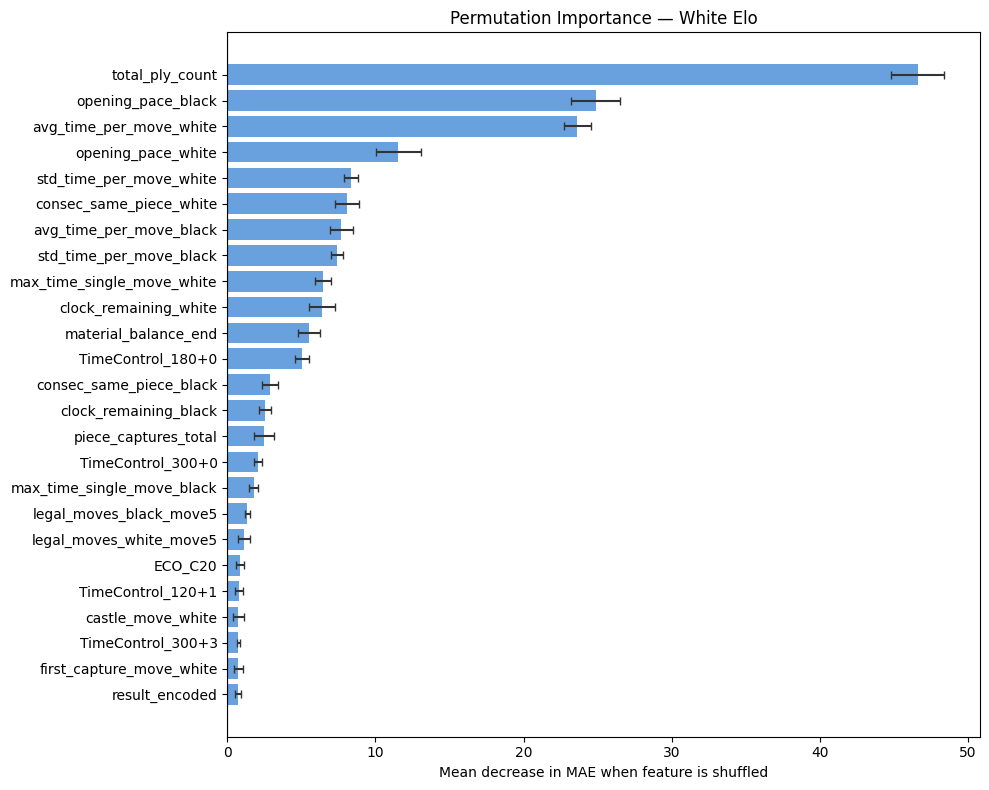

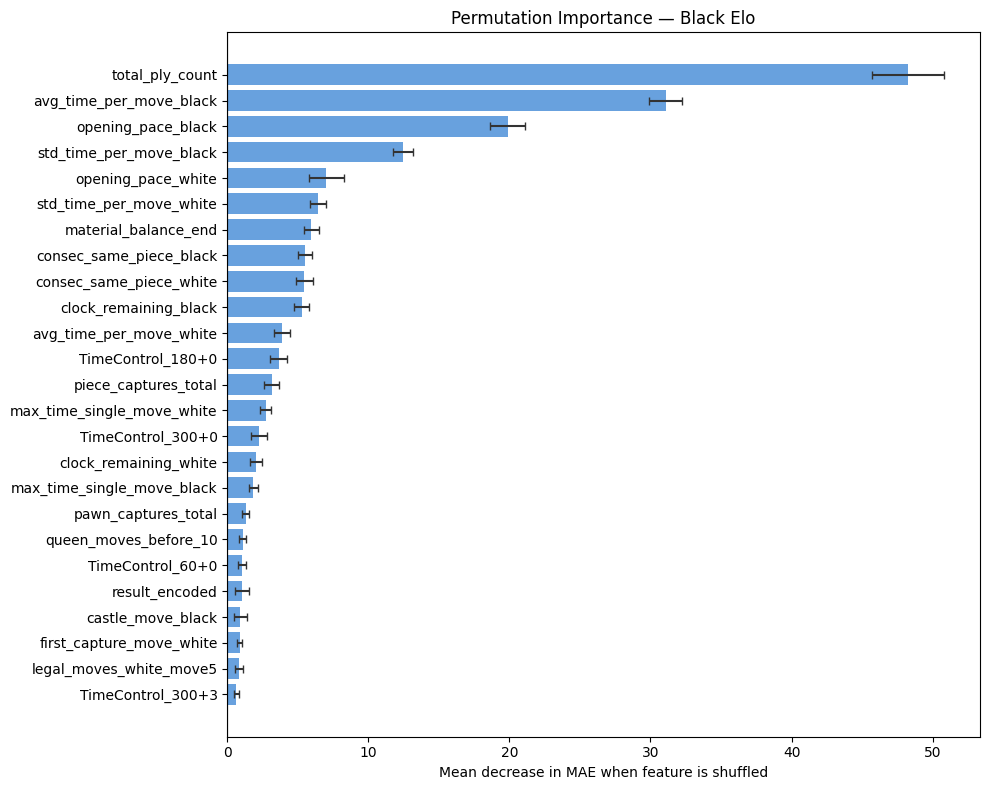

In [ ]:
def plot_perm_importance(df_imp: pd.DataFrame, title: str, top_n: int = 25):
    top = df_imp.head(top_n).iloc[::-1]   # reverse for horizontal bar
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top["feature"], top["importance"], xerr=top["std"],
                   color="#4e91d9", ecolor="#333", capsize=3, alpha=0.85)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Mean decrease in MAE when feature is shuffled")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_perm_importance(perm_white, "Permutation Importance — White Elo")
plot_perm_importance(perm_black,  "Permutation Importance — Black Elo")

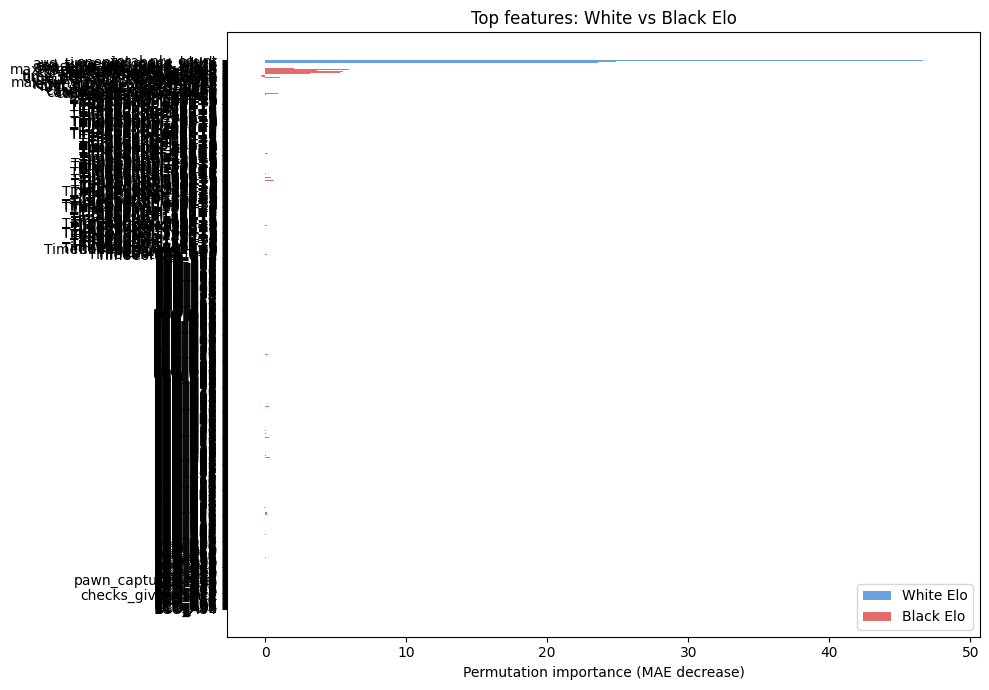

In [ ]:
# Side-by-side comparison of top features for White vs Black
top_n   = 15
merged  = (
    perm_white.head(top_n).rename(columns={"importance": "white_imp"})
    .merge(
        perm_black.rename(columns={"importance": "black_imp"}),
        on="feature", how="outer",
    )
    .fillna(0)
    .set_index("feature")[["white_imp", "black_imp"]]
    .sort_values("white_imp", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
x  = np.arange(len(merged))
bw = 0.4
ax.barh(x - bw/2, merged["white_imp"], bw, label="White Elo", color="#4e91d9", alpha=0.85)
ax.barh(x + bw/2, merged["black_imp"], bw, label="Black Elo", color="#e05252", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(merged.index)
ax.set_xlabel("Permutation importance (MAE decrease)")
ax.set_title("Top features: White vs Black Elo")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Diagnostic plots

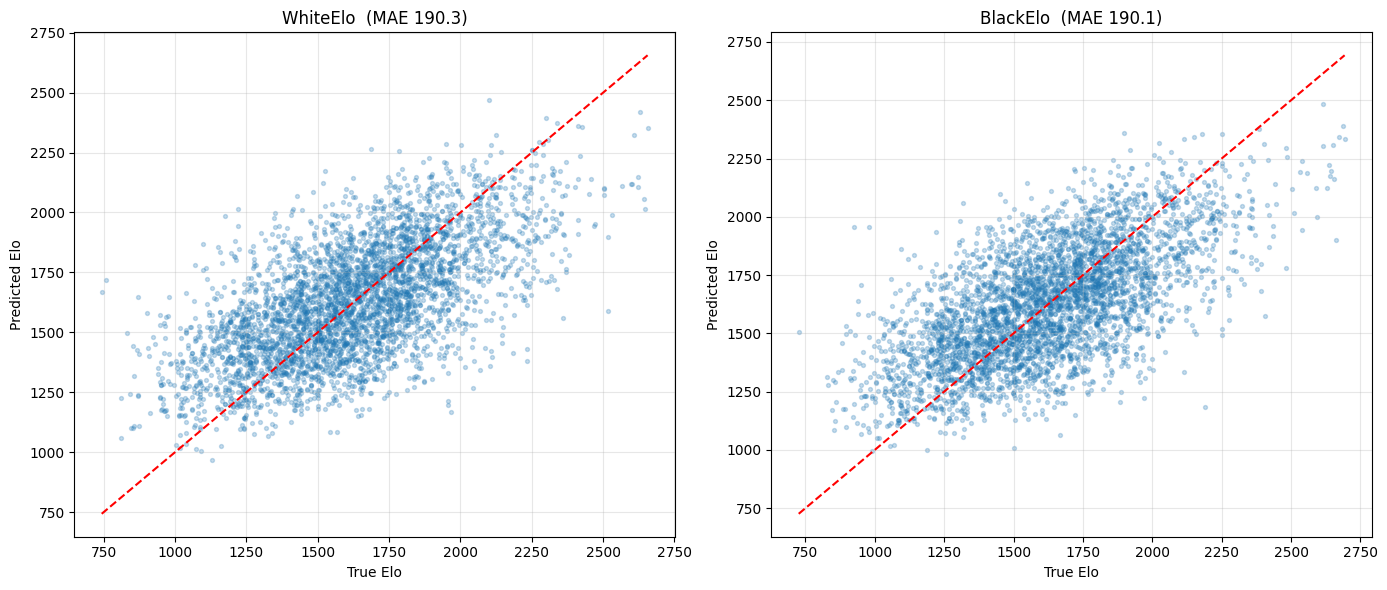

In [ ]:
# Truth vs prediction
def plot_predictions(run, ax):
    y_true, y_pred = run["y_test"], run["preds"]
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, rasterized=True)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
    ax.set_xlabel("True Elo")
    ax.set_ylabel("Predicted Elo")
    ax.set_title(f"{run['label']}  (MAE {run['mae']:.1f})")
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_predictions(white_run, axes[0])
plot_predictions(black_run,  axes[1])
plt.tight_layout()
plt.show()

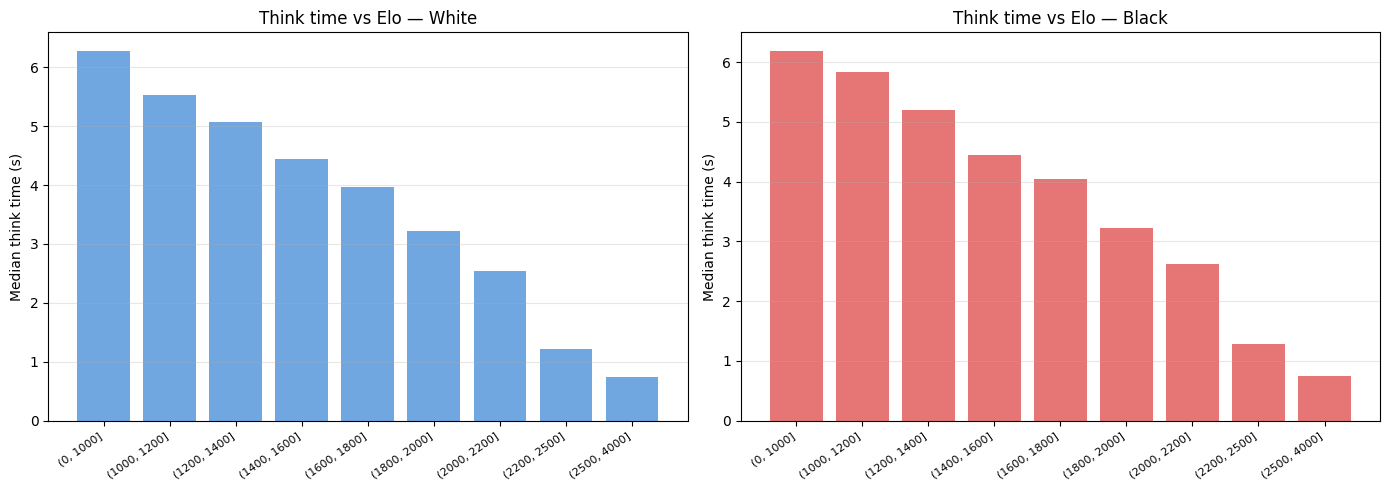

In [ ]:
# Clock features: average think time vs Elo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, elo_col, time_col, color in zip(
    axes,
    ["WhiteElo", "BlackElo"],
    ["avg_time_per_move_white", "avg_time_per_move_black"],
    ["#4e91d9", "#e05252"],
):
    # Bin Elo and show median think time per bin
    bins = pd.cut(df[elo_col], bins=ELO_BINS)
    med  = df.groupby(bins, observed=True)[time_col].median()
    ax.bar(range(len(med)), med.values, color=color, alpha=0.8, edgecolor='none')
    ax.set_xticks(range(len(med)))
    ax.set_xticklabels([str(b) for b in med.index], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("Median think time (s)")
    ax.set_title(f"Think time vs Elo — {elo_col[:5]}")
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

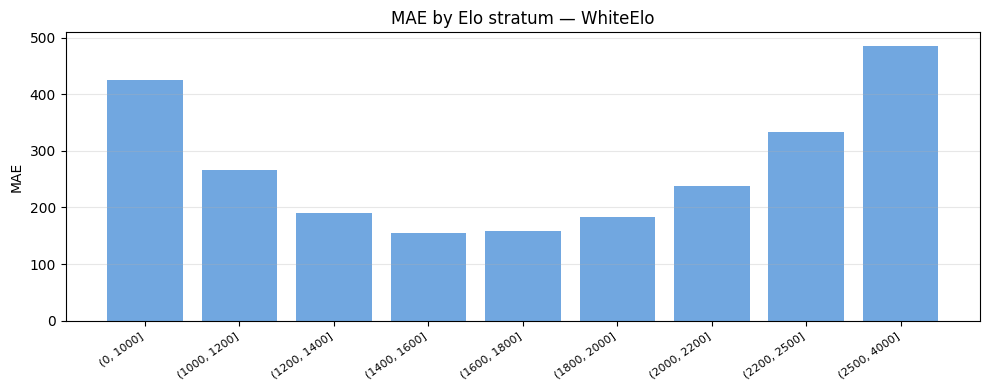

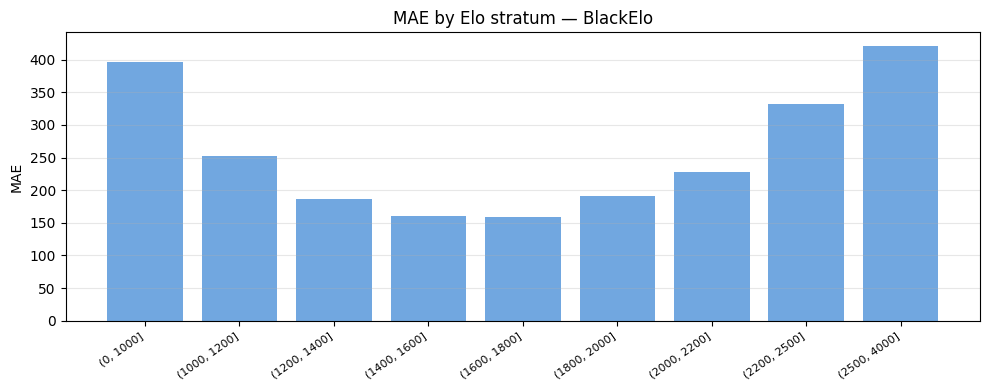

In [ ]:
# Residuals by Elo stratum — check if balanced weighting helped
for run, elo_col in [(white_run, "WhiteElo"), (black_run, "BlackElo")]:
    true_elo  = df[elo_col].values[run["idx_test"]]
    residuals = run["y_test"] - run["preds"]
    strata    = pd.cut(true_elo, bins=ELO_BINS)
    mae_by_stratum = pd.Series(np.abs(residuals)).groupby(strata, observed=True).mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(mae_by_stratum)), mae_by_stratum.values,
           color="#4e91d9", alpha=0.8, edgecolor='none')
    ax.set_xticks(range(len(mae_by_stratum)))
    ax.set_xticklabels([str(b) for b in mae_by_stratum.index], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("MAE")
    ax.set_title(f"MAE by Elo stratum — {run['label']}")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8 · Feature reference

| Feature | Description |
|---|---|
| `avg_time_per_move_*` | Mean seconds spent per move — strong Elo signal in bullet/blitz |
| `std_time_per_move_*` | Variance in think time — high variance may indicate tactical complexity awareness |
| `time_pressure_moves_*` | Moves played with < 10 s remaining |
| `opening_pace_*` | Average time on first 10 moves — strong players often play openings fast |
| `clock_remaining_*` | Seconds left at game end — flagging vs material/checkmate |
| `legal_moves_*_move5` | Opening complexity; computed from real board state (no heuristics) |
| `material_balance_end` | Piece value delta at final position |
| `white/black_territory_depth` | Max rank index a piece reached in enemy half |
| `queen_moves_before_10` | Early queen activity — classic beginner pattern |
| `consec_same_piece_*` | Piece shuffled back-and-forth — hesitation indicator |